In [1]:
import numpy as np
import wasserstein
import matplotlib.pyplot as plt

In [2]:
def compute_emds(points1, points2, B = 1):
    max_dist = np.sqrt(9.8**2 + (2*np.pi)**2)
    calc_emds = wasserstein.EMDYPhi(R=max_dist, 
                                            beta=B,
                                            norm=False,
                                            #num_threads=-1,
                                            #print_every=1000,
                                            #verbose=0,
                                            # request_mode=False,
                                            #store_sym_emds_raw=True,
                                            #throw_on_error=False,
                                            # omp_dynamic_chunksize=10,
                                            n_iter_max=100000,
                                            #epsilon_large_factor=1000.0,
                                            #epsilon_small_factor=1.0,
                                            dtype='float64')


    pts1 = points1[:,0]
    pts2 = points2[:,0]
    etaphi1 = points1[:,1:3]
    etaphi2 = points2[:,1:3]

    if B >= 1:
        distance = (calc_emds(pts1, etaphi1, pts2, etaphi2) - np.abs(pts1.sum() - pts2.sum()) )**(1/B) + np.abs(pts1.sum() - pts2.sum())

    else:
        distance = calc_emds(pts1, etaphi1, pts2, etaphi2)

    #print(f'beta = {B}')
    return distance

In [3]:
idx1 = 10000
idx2 = 8000
event1 = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/hardprocess_points.npy')[idx1]
event2 = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/hardprocess_points.npy')[idx2]
betas = np.logspace(-4,1,1000)

In [4]:
distances = []

for i in betas:
    distances.append(compute_emds(event1, event2, B = i))

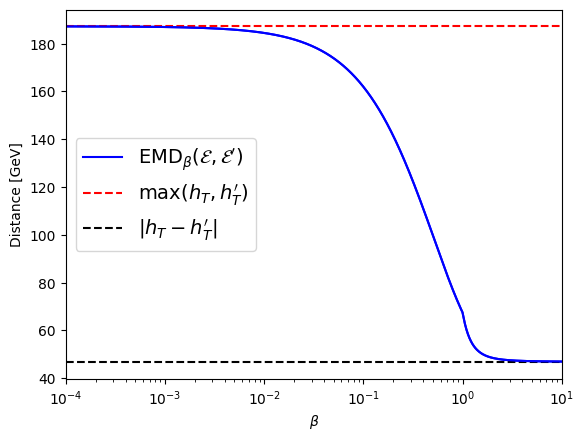

In [6]:
plt.plot(betas, distances, color = 'blue', label=r"$\text{EMD}_{\beta}(\mathcal{E}, \mathcal{E}')$")
plt.axhline(np.max([event1[:,0].sum(), event2[:,0].sum()]), color = 'red', linestyle = '--', label = r"$\text{max}(h_T, h_T')$")
plt.axhline(np.abs(event1[:,0].sum() - event2[:,0].sum()), color = 'black', linestyle = '--', label=r"$|h_T - h_T'|$")
plt.plot(betas, distances, color = 'blue')

plt.legend(fontsize = 14, loc = 'center left')
plt.xscale('log')
plt.xlim([1e-4, 1e1])
plt.xlabel(r"$\beta$")
plt.ylabel('Distance [GeV]')
plt.savefig('betas_plot.png')